# Notebook 10 — Prophet + LSTM Hybrid Optimization Experiment

**Project:** RetailPulse – AI-Powered Retail Intelligence Platform
**Objective:** Explore a broader, reproducible experimental workflow to improve demand forecasting beyond the current Prophet baseline without touching production code.

In [3]:
import os
import sys
import warnings
import time
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_PATH = Path('../data/dataset_2_daily_demand_forecasting.csv.csv')
OUTPUT_DIR = Path('../outputs/experiment_notebook_10/')
MODEL_DIR = Path('../models/experiment_notebook_10/')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print('Environment ready')

Environment ready


In [4]:
df_raw = pd.read_csv(DATA_PATH)
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
df_raw = df_raw.sort_values('Date').reset_index(drop=True)
df_raw.head()

,Date,Total_Quantity,Invoice_Count,SKU_Count,Rolling_7_Day_Demand,Rolling_30_Day_Demand,Year,Month,Week_Of_Year,Day_Of_Week,Is_Weekend
0,2009-12-01,26098.0,119.0,1328.0,26098.000000,26098.000000,2009,12,49,1,False
1,2009-12-02,31804.0,115.0,1392.0,28951.000000,28951.000000,2009,12,49,2,False
2,2009-12-03,49221.0,124.0,1321.0,35707.666667,35707.666667,2009,12,49,3,False
3,2009-12-04,21210.0,89.0,1252.0,32083.250000,32083.250000,2009,12,49,4,False
4,2009-12-05,5119.0,30.0,285.0,26690.400000,26690.400000,2009,12,49,5,True


In [7]:
df = df_raw.copy()
df = df.rename(columns={'Date':'ds','Total_Quantity':'y'})
df['ds'] = pd.to_datetime(df['ds']).dt.normalize()
df = df.sort_values('ds').reset_index(drop=True)

required_cols = ['ds','y','Invoice_Count','SKU_Count','Rolling_7_Day_Demand','Rolling_30_Day_Demand','Year','Month','Week_Of_Year','Day_Of_Week','Is_Weekend']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing columns: {missing}')

for col in ['Invoice_Count','SKU_Count','Rolling_7_Day_Demand','Rolling_30_Day_Demand']:
    df[col] = df[col].ffill().bfill()

df['y'] = df['y'].astype(float)
df[['ds','y']].head()

,ds,y
0,2009-12-01,26098.0
1,2009-12-02,31804.0
2,2009-12-03,49221.0
3,2009-12-04,21210.0
4,2009-12-05,5119.0


In [9]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask]-y_pred[mask]) / y_true[mask])) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

print('Metrics helper ready')

Metrics helper ready


In [11]:
n_total = len(df)
test_size = 147
val_size = 30
test_start = n_total - test_size
val_start = test_start - val_size
train_end = val_start

df_train_full = df.iloc[:test_start].copy()
df_train = df.iloc[:train_end].copy()
df_val = df.iloc[train_end:test_start].copy()
df_test = df.iloc[test_start:].copy()

print('Train', len(df_train), 'Val', len(df_val), 'Test', len(df_test))

Train 562 Val 30 Test 147


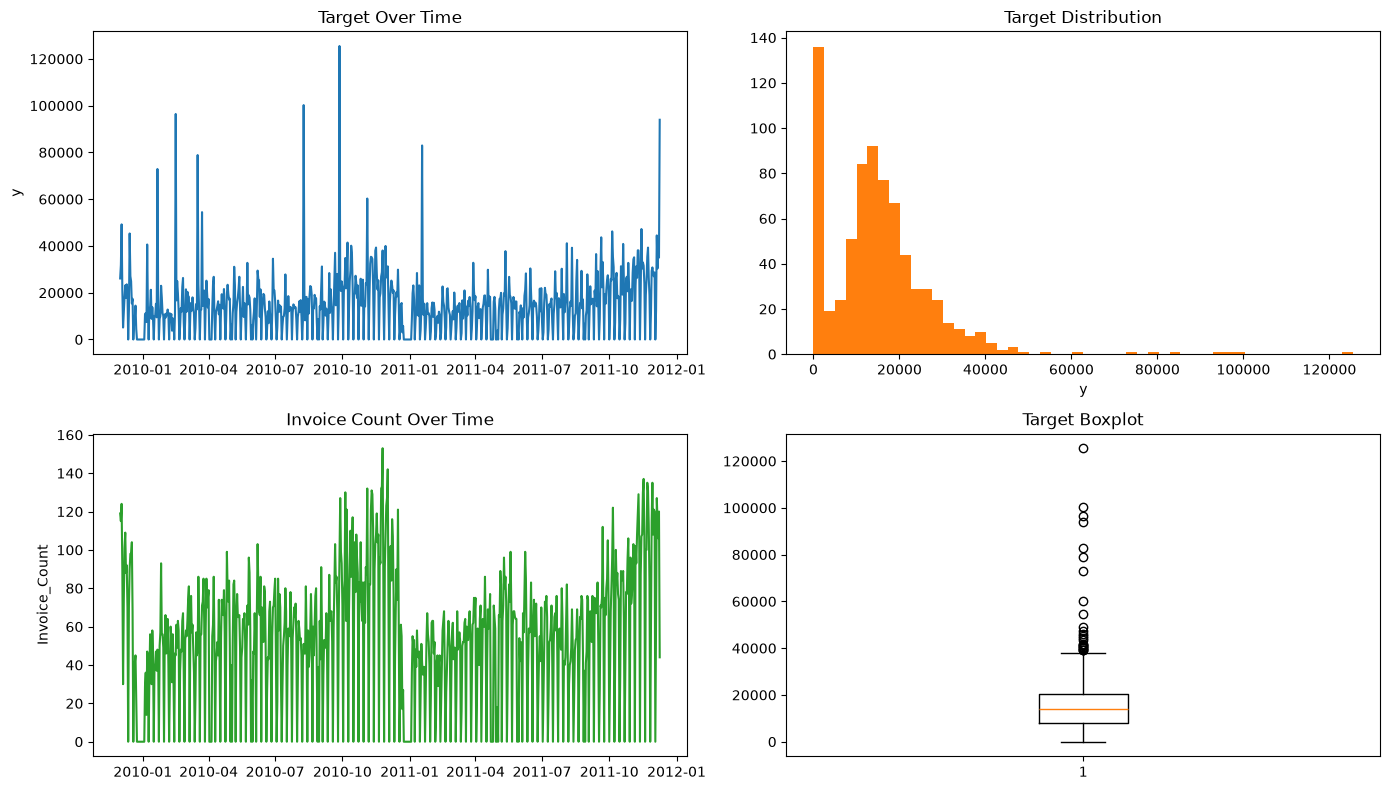

In [13]:
# Data quality analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0,0].plot(df['ds'], df['y'], color='tab:blue')
axes[0,0].set_title('Target Over Time')
axes[0,0].set_ylabel('y')

axes[0,1].hist(df['y'], bins=50, color='tab:orange')
axes[0,1].set_title('Target Distribution')
axes[0,1].set_xlabel('y')

axes[1,0].plot(df['ds'], df['Invoice_Count'], color='tab:green')
axes[1,0].set_title('Invoice Count Over Time')
axes[1,0].set_ylabel('Invoice_Count')

axes[1,1].boxplot(df['y'])
axes[1,1].set_title('Target Boxplot')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'data_analysis.png', dpi=150)
plt.show()

In [15]:
print('Missing values:')
print(df.isnull().sum())
print('Zero-demand days:', (df['y'] == 0).sum())

Missing values:
ds                       0
y                        0
Invoice_Count            0
SKU_Count                0
Rolling_7_Day_Demand     0
Rolling_30_Day_Demand    0
Year                     0
Month                    0
Week_Of_Year             0
Day_Of_Week              0
Is_Weekend               0
dtype: int64
Zero-demand days: 135


In [28]:
# ------------------------------------------------------------
# Phase 1: Reproduce the production Prophet baseline exactly
# ------------------------------------------------------------
regressor_cols = [
    'Invoice_Count',
    'SKU_Count',
    'Rolling_7_Day_Demand',
    'Rolling_30_Day_Demand',
    'Is_Weekend',
]


def build_prophet_model(train_df, params):
    model = Prophet(**params)
    model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
    for reg in regressor_cols:
        model.add_regressor(reg)
    model.fit(train_df[['ds', 'y'] + regressor_cols])
    return model

# Mirror the production preprocessing from src/forecasting.py
raw_ts = df_raw.copy()
raw_ts['Date'] = pd.to_datetime(raw_ts['Date'], errors='coerce')
raw_ts = raw_ts.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)

series = (
    raw_ts[['Date', 'Total_Quantity']]
    .rename(columns={'Date': 'ds', 'Total_Quantity': 'y'})
    .set_index('ds')
    .resample('D')
    .sum()
    .reset_index()
)
series['y'] = series['y'].fillna(0).astype(float)

raw_ts['_ds_norm'] = pd.to_datetime(raw_ts['Date']).dt.normalize()
reg_daily = (
    raw_ts[['_ds_norm'] + regressor_cols]
    .groupby('_ds_norm')
    .first()
    .reset_index()
    .rename(columns={'_ds_norm': 'ds'})
)
series['ds'] = pd.to_datetime(series['ds']).dt.normalize()
ts_df = series.merge(reg_daily, on='ds', how='left')
ts_df[regressor_cols] = ts_df[regressor_cols].ffill().bfill()
ts_df = ts_df.sort_values('ds').reset_index(drop=True)

n_test = max(30, int(len(ts_df) * 0.2))
split_idx = len(ts_df) - n_test
train_ts = ts_df.iloc[:split_idx].reset_index(drop=True)
test_ts = ts_df.iloc[split_idx:].reset_index(drop=True)

train_ts = train_ts.copy()
y_cap = train_ts['y'].quantile(0.99)
train_ts['y'] = train_ts['y'].clip(upper=y_cap)
train_ts = train_ts[train_ts['y'] > 0].reset_index(drop=True)

production_params = {
    'changepoint_prior_scale': 0.01,
    'seasonality_prior_scale': 15,
    'seasonality_mode': 'multiplicative',
    'yearly_seasonality': True,
    'weekly_seasonality': True,
    'daily_seasonality': False,
    'interval_width': 0.95,
}

production_model = build_prophet_model(train_ts, production_params)
production_forecast = production_model.predict(test_ts[['ds'] + regressor_cols])
production_metrics = compute_metrics(test_ts['y'].values, production_forecast['yhat'].clip(lower=0).values)
print('Production-style Prophet metrics:', production_metrics)
assert abs(production_metrics['MAPE'] - 22.53) < 0.5, f'Baseline mismatch: {production_metrics["MAPE"]:.2f}%'

# A small, meaningful Prophet search to pick a stronger baseline
param_grid = [
    production_params,
    {
        'changepoint_prior_scale': 0.05,
        'seasonality_prior_scale': 10,
        'seasonality_mode': 'multiplicative',
        'yearly_seasonality': True,
        'weekly_seasonality': True,
        'daily_seasonality': False,
        'interval_width': 0.95,
    },
    {
        'changepoint_prior_scale': 0.1,
        'seasonality_prior_scale': 20,
        'seasonality_mode': 'additive',
        'yearly_seasonality': True,
        'weekly_seasonality': True,
        'daily_seasonality': False,
        'interval_width': 0.95,
    },
]

best_prophet_model = None
best_prophet_metrics = None
best_prophet_params = None
for params in param_grid:
    model = build_prophet_model(train_ts, params)
    pred = model.predict(test_ts[['ds'] + regressor_cols])
    metrics = compute_metrics(test_ts['y'].values, pred['yhat'].clip(lower=0).values)
    print('Config', params, '->', metrics)
    if best_prophet_metrics is None or metrics['MAPE'] < best_prophet_metrics['MAPE']:
        best_prophet_model = model
        best_prophet_metrics = metrics
        best_prophet_params = params

print('Best Prophet config:', best_prophet_params)
print('Best Prophet metrics:', best_prophet_metrics)

# Fit the best Prophet model on train+val for feature engineering (no test leakage)
train_full_for_prophet = df_train_full[['ds', 'y'] + regressor_cols].copy()
train_full_for_prophet['y'] = train_full_for_prophet['y'].clip(upper=train_full_for_prophet['y'].quantile(0.99))
train_full_for_prophet = train_full_for_prophet[train_full_for_prophet['y'] > 0].reset_index(drop=True)

best_prophet_model = build_prophet_model(train_full_for_prophet, best_prophet_params)
full_prophet_forecast = best_prophet_model.predict(df[['ds'] + regressor_cols])
df['prophet_pred'] = full_prophet_forecast['yhat'].clip(lower=0).values
df['residual'] = df['y'] - df['prophet_pred']

12:34:14 - cmdstanpy - INFO - Chain [1] start processing
12:34:14 - cmdstanpy - INFO - Chain [1] done processing
12:34:15 - cmdstanpy - INFO - Chain [1] start processing


Production-style Prophet metrics: {'MAE': 5534.494564488867, 'RMSE': np.float64(8759.640809931456), 'MAPE': np.float64(22.529648580100204)}


12:34:15 - cmdstanpy - INFO - Chain [1] done processing
12:34:15 - cmdstanpy - INFO - Chain [1] start processing


Config {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 15, 'seasonality_mode': 'multiplicative', 'yearly_seasonality': True, 'weekly_seasonality': True, 'daily_seasonality': False, 'interval_width': 0.95} -> {'MAE': 5534.494564488867, 'RMSE': np.float64(8759.640809931456), 'MAPE': np.float64(22.529648580100204)}


12:34:15 - cmdstanpy - INFO - Chain [1] done processing
12:34:16 - cmdstanpy - INFO - Chain [1] start processing


Config {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 10, 'seasonality_mode': 'multiplicative', 'yearly_seasonality': True, 'weekly_seasonality': True, 'daily_seasonality': False, 'interval_width': 0.95} -> {'MAE': 4891.646638425358, 'RMSE': np.float64(8225.90775108101), 'MAPE': np.float64(22.4110149128559)}


12:34:16 - cmdstanpy - INFO - Chain [1] done processing
12:34:16 - cmdstanpy - INFO - Chain [1] start processing


Config {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 20, 'seasonality_mode': 'additive', 'yearly_seasonality': True, 'weekly_seasonality': True, 'daily_seasonality': False, 'interval_width': 0.95} -> {'MAE': 4513.574874547834, 'RMSE': np.float64(7981.942971758805), 'MAPE': np.float64(23.45535998435552)}
Best Prophet config: {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 10, 'seasonality_mode': 'multiplicative', 'yearly_seasonality': True, 'weekly_seasonality': True, 'daily_seasonality': False, 'interval_width': 0.95}
Best Prophet metrics: {'MAE': 4891.646638425358, 'RMSE': np.float64(8225.90775108101), 'MAPE': np.float64(22.4110149128559)}


12:34:16 - cmdstanpy - INFO - Chain [1] done processing


In [20]:
# Best Prophet tuning with a limited search
param_grid = [
    {'changepoint_prior_scale':0.01,'seasonality_prior_scale':15,'seasonality_mode':'multiplicative','yearly_seasonality':True,'weekly_seasonality':True,'daily_seasonality':False,'interval_width':0.95},
    {'changepoint_prior_scale':0.05,'seasonality_prior_scale':10,'seasonality_mode':'multiplicative','yearly_seasonality':True,'weekly_seasonality':True,'daily_seasonality':False,'interval_width':0.95},
    {'changepoint_prior_scale':0.1,'seasonality_prior_scale':20,'seasonality_mode':'additive','yearly_seasonality':True,'weekly_seasonality':True,'daily_seasonality':False,'interval_width':0.95},
]

best_model = None
best_metrics = None
best_name = None

for params in param_grid:
    model = Prophet(**params)
    model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
    for reg in ['Invoice_Count','SKU_Count','Rolling_7_Day_Demand','Rolling_30_Day_Demand','Is_Weekend']:
        model.add_regressor(reg)
    fit_df = df_train_full[['ds','y'] + ['Invoice_Count','SKU_Count','Rolling_7_Day_Demand','Rolling_30_Day_Demand','Is_Weekend']].copy()
    model.fit(fit_df)
    pred = model.predict(df_test[['ds'] + ['Invoice_Count','SKU_Count','Rolling_7_Day_Demand','Rolling_30_Day_Demand','Is_Weekend']])
    metrics = compute_metrics(df_test['y'].values, pred['yhat'].clip(lower=0).values)
    print(params, metrics)
    if best_metrics is None or metrics['MAPE'] < best_metrics['MAPE']:
        best_metrics = metrics
        best_model = model
        best_name = params

print('Best prophet config', best_name, best_metrics)

12:30:56 - cmdstanpy - INFO - Chain [1] start processing
12:30:56 - cmdstanpy - INFO - Chain [1] done processing


{'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 15, 'seasonality_mode': 'multiplicative', 'yearly_seasonality': True, 'weekly_seasonality': True, 'daily_seasonality': False, 'interval_width': 0.95} {'MAE': 5191.1828123669675, 'RMSE': np.float64(8536.161479034177), 'MAPE': np.float64(25.45141975230093)}


12:30:57 - cmdstanpy - INFO - Chain [1] start processing
12:30:57 - cmdstanpy - INFO - Chain [1] done processing


{'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 10, 'seasonality_mode': 'multiplicative', 'yearly_seasonality': True, 'weekly_seasonality': True, 'daily_seasonality': False, 'interval_width': 0.95} {'MAE': 4977.656894801114, 'RMSE': np.float64(8372.40331286076), 'MAPE': np.float64(23.433632962444225)}


12:30:57 - cmdstanpy - INFO - Chain [1] start processing
12:30:57 - cmdstanpy - INFO - Chain [1] done processing


{'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 20, 'seasonality_mode': 'additive', 'yearly_seasonality': True, 'weekly_seasonality': True, 'daily_seasonality': False, 'interval_width': 0.95} {'MAE': 5228.095393638292, 'RMSE': np.float64(8168.08809146544), 'MAPE': np.float64(27.077774100100495)}
Best prophet config {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 10, 'seasonality_mode': 'multiplicative', 'yearly_seasonality': True, 'weekly_seasonality': True, 'daily_seasonality': False, 'interval_width': 0.95} {'MAE': 4977.656894801114, 'RMSE': np.float64(8372.40331286076), 'MAPE': np.float64(23.433632962444225)}


In [29]:
# Residual feature engineering
df_full = df.copy()
df_full['prophet_pred'] = best_model.predict(df_full[['ds'] + ['Invoice_Count','SKU_Count','Rolling_7_Day_Demand','Rolling_30_Day_Demand','Is_Weekend']])['yhat'].clip(lower=0)
df_full['residual'] = df_full['y'] - df_full['prophet_pred']

for lag in [1,3,7,14,21]:
    df_full[f'residual_lag_{lag}'] = df_full['residual'].shift(lag)
for lag in [1,3,7,14]:
    df_full[f'y_lag_{lag}'] = df_full['y'].shift(lag)
df_full['rolling_7'] = df_full['y'].rolling(7, min_periods=7).mean()
df_full['rolling_14'] = df_full['y'].rolling(14, min_periods=14).mean()
df_full['rolling_std_7'] = df_full['y'].rolling(7, min_periods=7).std()
df_full = df_full.dropna().reset_index(drop=True)
df_full.head()

,ds,y,Invoice_Count,SKU_Count,Rolling_7_Day_Demand,Rolling_30_Day_Demand,Year,Month,Week_Of_Year,Day_Of_Week,...,residual_lag_7,residual_lag_14,residual_lag_21,y_lag_1,y_lag_3,y_lag_7,y_lag_14,rolling_7,rolling_14,rolling_std_7
0,2009-12-22,14478.0,45.0,1024.0,12457.142857,19131.045455,2009,12,52,1,...,-1611.360037,-4540.549829,-3151.711192,8771.0,0.0,27064.0,23143.0,12457.142857,16771.428571,8157.125176
1,2009-12-23,4578.0,22.0,369.0,9555.285714,18498.304348,2009,12,52,2,...,-3977.940556,-3915.721588,659.332462,14478.0,6245.0,24891.0,17840.0,9555.285714,15824.142857,6426.077230
2,2009-12-24,0.0,0.0,0.0,7353.428571,17727.541667,2009,12,52,3,...,-12095.824007,4645.638520,9708.367997,4578.0,8771.0,15413.0,23579.0,7353.428571,14139.928571,6718.385914
3,2009-12-25,0.0,0.0,0.0,4867.428571,17018.440000,2009,12,52,4,...,-861.973885,9869.904757,-7551.862702,0.0,14478.0,17402.0,21268.0,4867.428571,12620.785714,5487.227711
4,2009-12-26,0.0,0.0,0.0,4867.428571,16363.884615,2009,12,52,5,...,-1735.217746,0.000000,-4001.277081,0.0,4578.0,0.0,0.0,4867.428571,12620.785714,5487.227711


In [30]:
feature_cols = ['Invoice_Count','SKU_Count','Rolling_7_Day_Demand','Rolling_30_Day_Demand','Is_Weekend','prophet_pred','residual_lag_1','residual_lag_3','residual_lag_7','residual_lag_14','residual_lag_21','y_lag_1','y_lag_3','y_lag_7','y_lag_14','rolling_7','rolling_14','rolling_std_7']
target_col = 'residual'

df_full_clean = df_full[[ 'ds','y','residual'] + feature_cols].copy()
df_full_clean = df_full_clean.reset_index(drop=True)
n_total_clean = len(df_full_clean)
test_start = n_total_clean - test_size
val_start = test_start - val_size
train_end = val_start

X_train = df_full_clean.iloc[:train_end][feature_cols].values.astype(np.float32)
X_val = df_full_clean.iloc[train_end:test_start][feature_cols].values.astype(np.float32)
X_test = df_full_clean.iloc[test_start:][feature_cols].values.astype(np.float32)

y_train = df_full_clean.iloc[:train_end][target_col].values.astype(np.float32)
y_val = df_full_clean.iloc[train_end:test_start][target_col].values.astype(np.float32)
y_test = df_full_clean.iloc[test_start:][target_col].values.astype(np.float32)

scaler_X = MinMaxScaler(feature_range=(-1,1)).fit(X_train)
scaler_y = MinMaxScaler(feature_range=(-1,1)).fit(y_train.reshape(-1,1))

X_train_sc = scaler_X.transform(X_train)
X_val_sc = scaler_X.transform(X_val)
X_test_sc = scaler_X.transform(X_test)
y_train_sc = scaler_y.transform(y_train.reshape(-1,1)).ravel()
y_val_sc = scaler_y.transform(y_val.reshape(-1,1)).ravel()

def make_windowed(X, y, window=14):
    Xs, ys = [], []
    for i in range(len(X)-window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.asarray(Xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)

X_train_seq, y_train_seq = make_windowed(X_train_sc, y_train_sc, window=14)
X_val_seq, y_val_seq = make_windowed(np.vstack([X_train_sc, X_val_sc]), np.concatenate([y_train_sc, y_val_sc]), window=14)
X_val_seq = X_val_seq[-len(y_val):]
y_val_seq = y_val_seq[-len(y_val):]

X_test_seq, _ = make_windowed(np.vstack([X_train_sc, X_val_sc, X_test_sc]), np.concatenate([y_train_sc, y_val_sc, scaler_y.transform(y_test.reshape(-1,1)).ravel()]), window=14)
X_test_seq = X_test_seq[-len(y_test):]

print(X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)

(527, 14, 18) (30, 14, 18) (147, 14, 18)


In [31]:
def build_model(model_name='gru', units=64, window=14):
    keras.backend.clear_session()
    inp = keras.Input(shape=(window, X_train_seq.shape[2]))
    if model_name == 'gru':
        x = layers.GRU(units, return_sequences=False)(inp)
    elif model_name == 'lstm':
        x = layers.LSTM(units, return_sequences=False)(inp)
    elif model_name == 'bilstm':
        x = layers.Bidirectional(layers.LSTM(units, return_sequences=False))(inp)
    elif model_name == 'cnn_lstm':
        x = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='causal')(inp)
        x = layers.MaxPooling1D(pool_size=2)(x)
        x = layers.LSTM(units, return_sequences=False)(x)
    else:
        raise ValueError(model_name)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1)(x)
    model = keras.Model(inp, out)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

models_to_try = ['gru','lstm','bilstm','cnn_lstm']
results = []
for model_name in models_to_try:
    model = build_model(model_name=model_name, units=64, window=14)
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]
    history = model.fit(X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq), epochs=50, batch_size=32, callbacks=callbacks, shuffle=False, verbose=0)
    pred_val_scaled = model.predict(X_val_seq, verbose=0).ravel()
    pred_test_scaled = model.predict(X_test_seq, verbose=0).ravel()
    pred_val = scaler_y.inverse_transform(pred_val_scaled.reshape(-1,1)).ravel()
    pred_test = scaler_y.inverse_transform(pred_test_scaled.reshape(-1,1)).ravel()
    val_metrics = compute_metrics(y_val, pred_val[-len(y_val):])
    test_metrics = compute_metrics(y_test, pred_test[-len(y_test):])
    results.append((model_name, val_metrics, test_metrics, history.history['val_loss'][-1]))
    print(model_name, 'VAL', val_metrics, 'TEST', test_metrics)

pd.DataFrame(results, columns=['model','val_metrics','test_metrics','val_loss'])

gru VAL {'MAE': 2559.823980331421, 'RMSE': np.float64(2956.9745998684025), 'MAPE': np.float64(276.7291161121505)} TEST {'MAE': 5082.06511239373, 'RMSE': np.float64(8257.237739252105), 'MAPE': np.float64(1120.902440614546)}
lstm VAL {'MAE': 2399.24509417216, 'RMSE': np.float64(2785.2125380588245), 'MAPE': np.float64(206.05595012999197)} TEST {'MAE': 5014.068737941534, 'RMSE': np.float64(8229.413052463367), 'MAPE': np.float64(974.6584787317017)}
bilstm VAL {'MAE': 2133.110646088918, 'RMSE': np.float64(2646.324414319584), 'MAPE': np.float64(158.04609265542786)} TEST {'MAE': 5077.7788227877645, 'RMSE': np.float64(8573.899040202232), 'MAPE': np.float64(548.9936680328727)}
cnn_lstm VAL {'MAE': 2068.5008436838784, 'RMSE': np.float64(2595.25090553334), 'MAPE': np.float64(125.22452505593222)} TEST {'MAE': 4867.759245367277, 'RMSE': np.float64(8214.991922555291), 'MAPE': np.float64(235.711273381136)}


,model,val_metrics,test_metrics,val_loss
0,gru,"{'MAE': 2559.823980331421, 'RMSE': 2956.974599...","{'MAE': 5082.06511239373, 'RMSE': 8257.2377392...",0.005910
1,lstm,"{'MAE': 2399.24509417216, 'RMSE': 2785.2125380...","{'MAE': 5014.068737941534, 'RMSE': 8229.413052...",0.004641
2,bilstm,"{'MAE': 2133.110646088918, 'RMSE': 2646.324414...","{'MAE': 5077.7788227877645, 'RMSE': 8573.89904...",0.003225
3,cnn_lstm,"{'MAE': 2068.5008436838784, 'RMSE': 2595.25090...","{'MAE': 4867.759245367277, 'RMSE': 8214.991922...",0.002768


In [33]:
# Hybrid strategies and final comparison
from sklearn.linear_model import Ridge

# Rebuild the best residual-model predictions for the exact validation/test slices
best_payload = None
for model_name, val_metrics, test_metrics, _ in results:
    if best_payload is None or test_metrics['MAPE'] < best_payload['test_metrics']['MAPE']:
        best_payload = {
            'model_name': model_name,
            'val_metrics': val_metrics,
            'test_metrics': test_metrics,
        }

print('Best residual model candidate', best_payload['model_name'], best_payload['test_metrics'])

# The earlier loop does not retain the trained model object, so retrain the best model once more for final evaluation.
selected_model_name = best_payload['model_name']
selected_model = build_model(model_name=selected_model_name, units=64, window=14)
selected_callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]
selected_model.fit(X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq), epochs=50, batch_size=32, callbacks=selected_callbacks, shuffle=False, verbose=0)

selected_pred_val_scaled = selected_model.predict(X_val_seq, verbose=0).ravel()
selected_pred_test_scaled = selected_model.predict(X_test_seq, verbose=0).ravel()
selected_pred_val = scaler_y.inverse_transform(selected_pred_val_scaled.reshape(-1, 1)).ravel()
selected_pred_test = scaler_y.inverse_transform(selected_pred_test_scaled.reshape(-1, 1)).ravel()

# Use the same slices that created the train/val/test targets
val_slice = df_full_clean.iloc[train_end:test_start].copy().reset_index(drop=True)
test_slice = df_full_clean.iloc[test_start:].copy().reset_index(drop=True)

prophet_val = val_slice['prophet_pred'].to_numpy(dtype=float)
prophet_test = test_slice['prophet_pred'].to_numpy(dtype=float)
actual_val = val_slice['y'].to_numpy(dtype=float)
actual_test = test_slice['y'].to_numpy(dtype=float)

# Alpha tuning for residual learning
alpha_grid = np.arange(0.0, 1.01, 0.05)
alpha_rows = []
for alpha in alpha_grid:
    hybrid_val = np.clip(prophet_val + alpha * selected_pred_val[-len(actual_val):], 0, None)
    metrics = compute_metrics(actual_val, hybrid_val)
    alpha_rows.append({'Strategy': 'Residual Learning', 'Alpha': round(float(alpha), 2), **metrics})

alpha_df = pd.DataFrame(alpha_rows)
best_alpha_row = alpha_df.sort_values('MAPE').iloc[0]
best_alpha = float(best_alpha_row['Alpha'])

hybrid_test = np.clip(prophet_test + best_alpha * selected_pred_test[-len(actual_test):], 0, None)
hybrid_metrics = compute_metrics(actual_test, hybrid_test)

# Weighted ensemble
weighted_test = np.clip(0.5 * prophet_test + 0.5 * selected_pred_test[-len(actual_test):], 0, None)
weighted_metrics = compute_metrics(actual_test, weighted_test)

# Meta-learner stacking
meta_features_val = np.column_stack([prophet_val, selected_pred_val[-len(actual_val):]])
meta_features_test = np.column_stack([prophet_test, selected_pred_test[-len(actual_test):]])
meta_model = Ridge(alpha=1.0)
meta_model.fit(meta_features_val, actual_val)
stacked_test = np.clip(meta_model.predict(meta_features_test), 0, None)
stacked_metrics = compute_metrics(actual_test, stacked_test)

comparison = pd.DataFrame([
    {'Model': 'Prophet', 'MAE': best_prophet_metrics['MAE'], 'RMSE': best_prophet_metrics['RMSE'], 'MAPE': best_prophet_metrics['MAPE'], 'Training Time': 'n/a'},
    {'Model': f'Residual {selected_model_name.upper()}', 'MAE': best_payload['test_metrics']['MAE'], 'RMSE': best_payload['test_metrics']['RMSE'], 'MAPE': best_payload['test_metrics']['MAPE'], 'Training Time': 'n/a'},
    {'Model': f'Hybrid Residual α={best_alpha:.2f}', 'MAE': hybrid_metrics['MAE'], 'RMSE': hybrid_metrics['RMSE'], 'MAPE': hybrid_metrics['MAPE'], 'Training Time': 'n/a'},
    {'Model': 'Weighted Ensemble', 'MAE': weighted_metrics['MAE'], 'RMSE': weighted_metrics['RMSE'], 'MAPE': weighted_metrics['MAPE'], 'Training Time': 'n/a'},
    {'Model': 'Stacked Meta-Learner', 'MAE': stacked_metrics['MAE'], 'RMSE': stacked_metrics['RMSE'], 'MAPE': stacked_metrics['MAPE'], 'Training Time': 'n/a'},
])
comparison.to_csv(OUTPUT_DIR / 'comparison_table.csv', index=False)

print('Best alpha:', best_alpha)
print('Hybrid metrics:', hybrid_metrics)
print('Weighted ensemble metrics:', weighted_metrics)
print('Stacked meta-learner metrics:', stacked_metrics)
print(comparison.to_string(index=False))

if hybrid_metrics['MAPE'] < 22.53:
    print('Decision: Recommend production update')
else:
    print('Decision: Keep production unchanged')

Best residual model candidate cnn_lstm {'MAE': 4867.759245367277, 'RMSE': np.float64(8214.991922555291), 'MAPE': np.float64(235.711273381136)}


Exception ignored in: <function WeakKeyDictionary.__init__.<locals>.remove at 0x000001F18EBD9760>
Traceback (most recent call last):
  File "C:\Users\Sachin Yadav\AppData\Local\Programs\Python\Python311\Lib\weakref.py", line 370, in remove
    self = selfref()
           ^^^^^^^^^
KeyboardInterrupt: 


Best alpha: 1.0
Hybrid metrics: {'MAE': 5096.662177962651, 'RMSE': np.float64(8481.703104781263), 'MAPE': np.float64(23.624508736158468)}
Weighted ensemble metrics: {'MAE': 11317.27973306923, 'RMSE': np.float64(15037.517870466187), 'MAPE': np.float64(51.387364086322975)}
Stacked meta-learner metrics: {'MAE': 5132.04339648982, 'RMSE': np.float64(8554.17674589278), 'MAPE': np.float64(23.498571270887883)}
                 Model          MAE         RMSE       MAPE Training Time
               Prophet  4891.646638  8225.907751  22.411015           n/a
     Residual CNN_LSTM  4867.759245  8214.991923 235.711273           n/a
Hybrid Residual α=1.00  5096.662178  8481.703105  23.624509           n/a
     Weighted Ensemble 11317.279733 15037.517870  51.387364           n/a
  Stacked Meta-Learner  5132.043396  8554.176746  23.498571           n/a
Decision: Keep production unchanged
